# Figure S3D: pseudotime distributions

Run cells from top to bottom. Paths, thread limits, and shared annotations are stored with the supporting files in `notebooks/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("notebooks/paths.R")) "." else if (file.exists("../notebooks/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "notebooks", "paths.R"))


Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built under R 4.4.1 but the current version is
4.4.2; it is recomended that you reinstall ‘SeuratObject’ as the ABI
for R may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, 

Running louvain iteration  1 ...


Maximal modularity is 0.905958670615628; corresponding resolution is No resolution


Run kNN based graph clustering DONE, totally takes 0.367333173751831 s.



  -Number of clusters: 26 
  |======================================================================| 100%


Running graph pruning ...


Projecting cells to principal points for partition: 1

Warning message:
“Monocle 3 trajectories require cluster partitions, which Seurat does not calculate. Please run 'cluster_cells' on your cell_data_set object”
nn_control: 

    method: NA

    metric: NA

set_nn_control: call stack: IRkernel::main() => kernel$run() => handle_shell() => executor$execute() => tryCatch() => tryCatchList() => tryCatchOne() => doTryCatch() => tryCatchList() => tryCatchOne() => doTryCatch() => evaluate() => withRestarts() => withRestartList() => withOneRestart() => doWithOneRestart() => withRestartList() => withOneRestart() => doWithOneRestart() => with_handlers() => eval() => eval() => withCallingHandlers() => withVisible() => eval() => eval() => learn_graph() => set_nn_control()

  nn_control: 

    method: annoy

    metric: euclidean

    n_trees: 50

    search_k: 2500

    cores: 1

    grain_size: 1

Processing partition component 1

Current partition is 1

Using 887 no

Running louvain iteration  1 ...


Maximal modularity is 0.906536368027848; corresponding resolution is No resolution


Run kNN based graph clustering DONE, totally takes 0.356475353240967 s.



  -Number of clusters: 27 
  |======================================================================| 100%

edge_vec is 485	37

edge_vec_in_tip_pc_point is WT_TTGTTTGTCGCAGAGA-1	WT_GACTTCCAGCGTTCCG-1

edge_vec is 395	269

edge_vec_in_tip_pc_point is WT_GAGGGATGTATCGAAA-1	WT_ACTTAGGAGCCTATTG-1

edge_vec is 269	395

edge_vec_in_tip_pc_point is WT_ACTTAGGAGCCTATTG-1	WT_GAGGGATGTATCGAAA-1

edge_vec is 37	485

edge_vec_in_tip_pc_point is WT_GACTTCCAGCGTTCCG-1	WT_TTGTTTGTCGCAGAGA-1



Running graph pruning ...


Projecting cells to principal points for partition: 1

Unified pseudotime scale set to: 0 to 34.89

Cells aren't colored in a way that allows them to be grouped.

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the monocle3 package.
  Please report the issue to the authors.”
Scale for colour is already present.
Addi

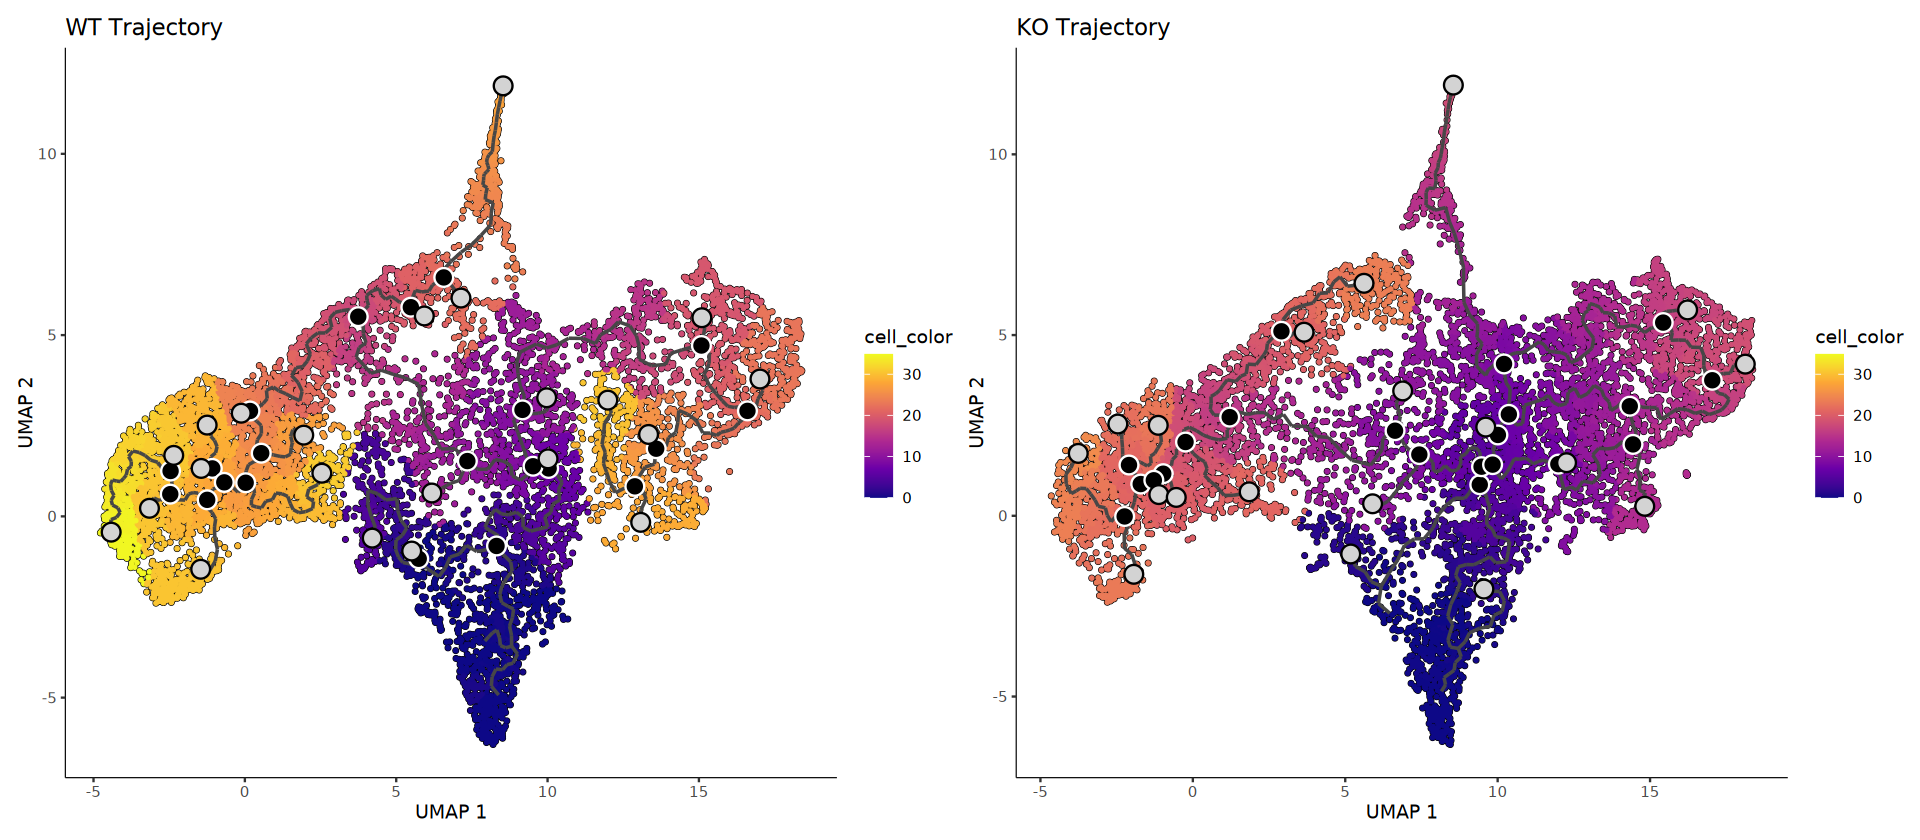

In [1]:
library(Seurat)
library(SeuratWrappers)
library(monocle3)
library(future)
library(ggplot2)
library(patchwork)
library(viridis) # 用于提供颜色方案

# 设置并行计算
plan("multicore", workers = p38_workers)
options(future.globals.maxSize = Inf)

# 加载Seurat对象
seu <- readRDS(p38_path("20250604p38-afterYZ/anno.rds"))
seu[["RNA"]] <- JoinLayers(seu[["RNA"]])
seu_filtered <- subset(seu, cells = colnames(seu)) # 假设不过滤

# ===================================================================
# ================== 1. 完全独立的轨迹分析（你的原始逻辑） ==================
# ===================================================================

# --- 处理WT数据 ---
wt_seu <- subset(seu_filtered, subset = orig.ident == "WT")
wt_cds <- as.cell_data_set(wt_seu, assay = "RNA")
reducedDims(wt_cds)$UMAP <- wt_seu[["umap"]]@cell.embeddings
partitions_wt <- setNames(rep(1, ncol(wt_cds)), colnames(wt_cds))
wt_cds@clusters$UMAP <- list(clusters = wt_seu$RNA_snn_res.0.8, partitions = partitions_wt)
wt_cds <- learn_graph(wt_cds, use_partition = FALSE, verbose = TRUE)
wt_root_cells <- which(wt_seu$RNA_snn_res.0.8 == "6")
if(length(wt_root_cells) > 0) {
  wt_cds <- order_cells(wt_cds, root_cells = colnames(wt_cds)[wt_root_cells])
} else {
  warning("No cells from cluster 6 found in WT data. Trajectory ordering skipped.")
}

# --- 处理KO数据 ---
ko_seu <- subset(seu_filtered, subset = orig.ident == "KO")
ko_cds <- as.cell_data_set(ko_seu, assay = "RNA")
reducedDims(ko_cds)$UMAP <- ko_seu[["umap"]]@cell.embeddings
partitions_ko <- setNames(rep(1, ncol(ko_cds)), colnames(ko_cds))
ko_cds@clusters$UMAP <- list(clusters = ko_seu$RNA_snn_res.0.8, partitions = partitions_ko)
ko_cds <- learn_graph(ko_cds, use_partition = FALSE, verbose = TRUE)
ko_root_cells <- which(ko_seu$RNA_snn_res.0.8 == "6")
if(length(ko_root_cells) > 0) {
  ko_cds <- order_cells(ko_cds, root_cells = colnames(ko_cds)[ko_root_cells])
} else {
  warning("No cells from cluster 6 found in KO data. Trajectory ordering skipped.")
}


# ===================================================================
# ======================== 2. 统一颜色标尺并优化绘图 (最终修正版) ========================
# ===================================================================

# 检查pseudotime是否都已计算
if (!is.null(pseudotime(wt_cds)) && !is.null(pseudotime(ko_cds))) {

  # --- 步骤A: 找到全局的pseudotime范围 (这部分不变) ---
  all_pseudotimes <- c(pseudotime(wt_cds)[is.finite(pseudotime(wt_cds))], 
                       pseudotime(ko_cds)[is.finite(pseudotime(ko_cds))])
  
  if (length(all_pseudotimes) == 0) {
      stop("No finite pseudotime values found in either WT or KO datasets.")
  }
  
  min_pseudo <- min(all_pseudotimes, na.rm = TRUE)
  max_pseudo <- max(all_pseudotimes, na.rm = TRUE)
  global_limits <- c(min_pseudo, max_pseudo)
  
  message(paste("Unified pseudotime scale set to:", round(global_limits[1], 2), "to", round(global_limits[2], 2)))

  # --- 步骤B: 强制绘图节点，然后手动隐藏数字 ---
  
  # --- WT Plot ---
  plot_wt <- plot_cells(
    wt_cds,
    color_cells_by = "pseudotime",
    show_trajectory_graph = TRUE,
    
    # --- 步骤 1: 强制绘图节点和标签 ---
    label_branch_points = TRUE, # 必须为 TRUE
    label_leaves = TRUE,        # 必须为 TRUE
    graph_label_size = 3,       # 设置节点圆圈的大小
    # -----------------------------------

    label_groups_by_cluster = FALSE,
    label_roots = FALSE,
    cell_size = 0.75
  ) 
  
  # --- 步骤 2: 手动移除文本标签 ---
  # 遍历ggplot对象的所有图层
  for (i in 1:length(plot_wt$layers)) {
    # 找到负责绘制文本的图层 (GeomText)
    if (inherits(plot_wt$layers[[i]]$geom, "GeomText")) {
      # 将该图层的标签设置为空字符串，使其不可见
      plot_wt$layers[[i]]$aes_params$label <- ""
    }
  }
  
  # 添加标题和颜色标尺
  plot_wt <- plot_wt + 
    ggtitle("WT Trajectory") +
    ggplot2::scale_color_viridis_c(option = "C", name = "cell_color", limits = global_limits)

  # --- KO Plot (重复以上步骤) ---
  plot_ko <- plot_cells(
    ko_cds,
    color_cells_by = "pseudotime", 
    show_trajectory_graph = TRUE,
    
    # --- 步骤 1: 强制绘图节点和标签 ---
    label_branch_points = TRUE,
    label_leaves = TRUE,
    graph_label_size = 3,
    # -----------------------------------
    
    label_groups_by_cluster = FALSE,
    label_roots = FALSE,
    cell_size = 0.75
  )

  # --- 步骤 2: 手动移除文本标签 ---
  for (i in 1:length(plot_ko$layers)) {
    if (inherits(plot_ko$layers[[i]]$geom, "GeomText")) {
      plot_ko$layers[[i]]$aes_params$label <- ""
    }
  }
  
  # 添加标题和颜色标尺
  plot_ko <- plot_ko + 
    ggtitle("KO Trajectory") +
    ggplot2::scale_color_viridis_c(option = "C", name = "cell_color", limits = global_limits)


  # 合并显示
  combined_plot <- plot_wt + plot_ko
  options(repr.plot.width = 16, repr.plot.height = 7)
  print(combined_plot)
  
} else {
    warning("Pseudotime calculation was skipped for at least one condition. Plotting aborted.")
}

### Interpretation note

在 WT 中到达终点需要 15 个单位，而在 KO 中只到了 10 个单位”，但这并不绝对等于“KO 细胞发育慢了”，也可能是“KO 细胞死掉了”或“KO 细胞停滞了”。只要你解释时强调这是“流形距离”的对比，这种做法是可以的。


In [2]:
# 1. 定义保存路径和文件名
save_dir <- p38_path("20260126p38拟时序修图")
save_file <- file.path(save_dir, "monocle3_results_combined.rds")

# 2. 如果文件夹不存在则创建
if (!dir.exists(save_dir)) {
  dir.create(save_dir, recursive = TRUE)
}

# 3. 将所有想要保存的对象打包进一个列表 (List)
# 这里包含 WT 对象、KO 对象，甚至可以包含你画好的图
save_list <- list(
  wt_cds = wt_cds,
  ko_cds = ko_cds,
  combined_plot = combined_plot,
  global_limits = global_limits  # 保存一下统一的拟时序范围，以后有用
)

# 4. 保存为单个 RDS 文件
saveRDS(save_list, file = save_file)

message("所有分析结果已合并保存至: ", save_file)

所有分析结果已合并保存至: /data3/Group8/gonglihao/项目/p38/20260126p38拟时序修图/monocle3_results_combined.rds



In [ ]:
# 读取合并的文件
res <- readRDS(p38_path("20260126p38拟时序修图/monocle3_results_combined.rds"))

# 通过列表索引提取对象
wt_cds <- res$wt_cds
ko_cds <- res$ko_cds
plot_result <- res$combined_plot

# 直接显示图片
print(plot_result)

In [ ]:
my_colors <- c("WT" = "#8abbf9", "KO" = "#D62728")

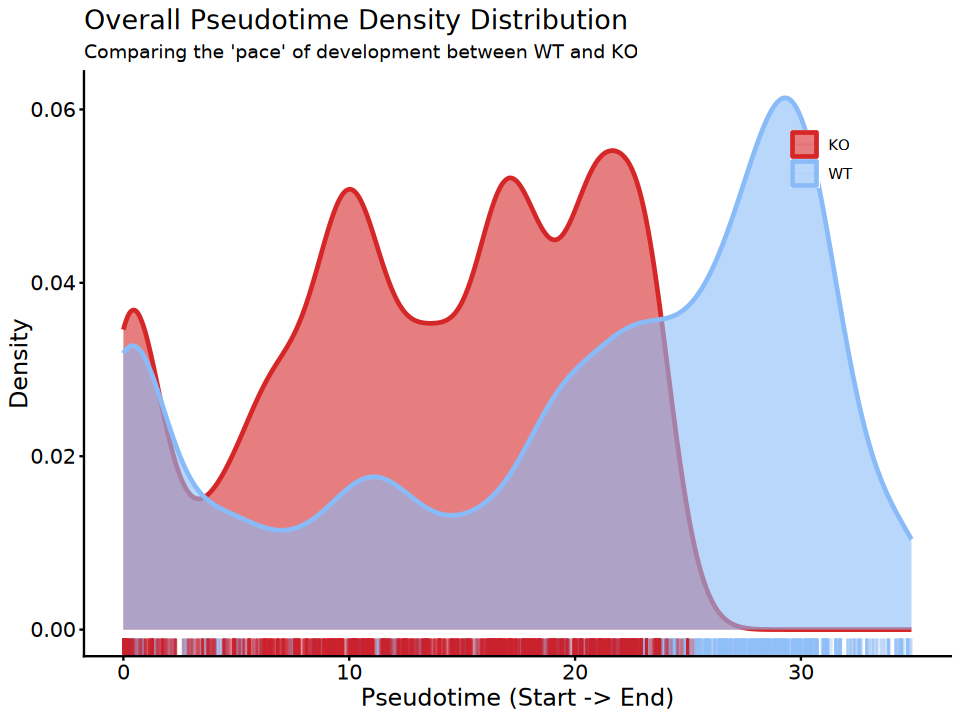

In [4]:
library(ggplot2)
library(dplyr)
library(scales)

# ===================================================================
# 0. 数据准备 (构建 df_all)
# ===================================================================
# 从上一步生成的 cds 对象中提取 pseudotime
# 注意：只提取有限值 (finite values)
wt_pt <- pseudotime(wt_cds)
ko_pt <- pseudotime(ko_cds)

# 构建绘图数据框
df_wt <- data.frame(
  Pseudotime = wt_pt[is.finite(wt_pt)], 
  orig.ident = "WT"
)
df_ko <- data.frame(
  Pseudotime = ko_pt[is.finite(ko_pt)], 
  orig.ident = "KO"
)

df_all <- rbind(df_wt, df_ko)

# 定义颜色
my_colors <- c("WT" = "#8abbf9", "KO" = "#D62728")

# ===================================================================
# 1. 绘制密度分布图 (仅保留此图，并修改透明度)
# ===================================================================

p_density <- ggplot(df_all, aes(x = Pseudotime, color = orig.ident, fill = orig.ident)) +
  # 修改：alpha 改为 0.6
  geom_density(alpha = 0.6, size = 1) + 
  geom_rug(alpha = 0.1) +               
  scale_fill_manual(values = my_colors) +
  scale_color_manual(values = my_colors) +
  labs(
    title = "Overall Pseudotime Density Distribution",
    subtitle = "Comparing the 'pace' of development between WT and KO",
    x = "Pseudotime (Start -> End)",
    y = "Density"
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14),
    legend.position = c(0.85, 0.85), # 图例在右上角
    legend.title = element_blank(),
    legend.background = element_rect(fill = "transparent") # 图例背景透明
  )

# ===================================================================
# 2. 打印图表
# ===================================================================
options(repr.plot.width = 8, repr.plot.height = 6) # 调整为适合单张图的大小
print(p_density)

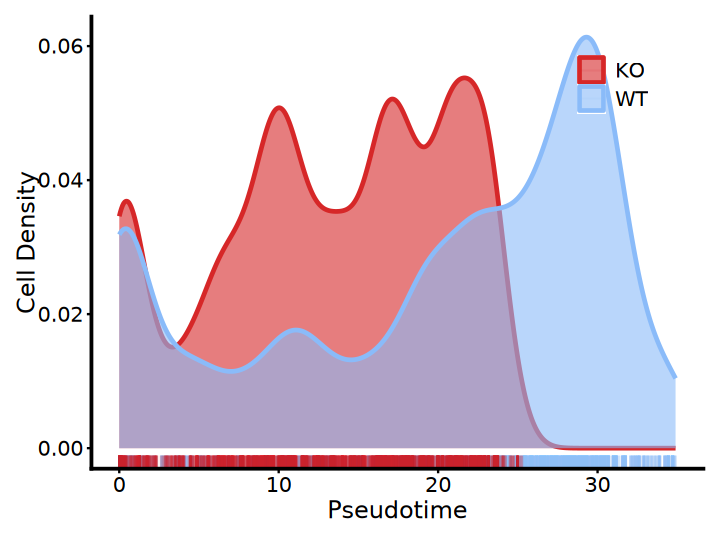

In [5]:
library(ggplot2)

# 确保 df_all 和 my_colors 已经定义 (沿用上一个单元格的数据)

p_density_pub <- ggplot(df_all, aes(x = Pseudotime, color = orig.ident, fill = orig.ident)) +
  # 保持你的要求：透明度 0.6
  geom_density(alpha = 0.6, size = 1) + 
  geom_rug(alpha = 0.1) +               
  scale_fill_manual(values = my_colors) +
  scale_color_manual(values = my_colors) +
  
  # --- 修改部分：规范化标签 ---
  labs(
    x = "Pseudotime",      # 简单明了，不要加括号解释
    y = "Cell Density",    # 强调是细胞密度
    title = NULL,          # 发表级作图通常不需要图内标题
    subtitle = NULL        # 移除副标题
  ) +
  # -------------------------
  
  theme_classic() + # 或者 theme_bw() 也是常用的
  theme(
    # 坐标轴线条加粗一点，显得更有质感
    axis.line = element_line(linewidth = 0.8),
    
    # 字体大小调整 (根据最终拼图大小调整，通常 12-14 是合适的)
    axis.text = element_text(size = 12, color = "black"),
    axis.title = element_text(size = 14, face = "bold", color = "black"),
    
    # 图例设置
    legend.position = c(0.85, 0.85), 
    legend.title = element_blank(),
    legend.text = element_text(size = 12),
    legend.background = element_blank(), # 移除图例背景框
    
    # 移除不必要的空白
    plot.margin = margin(10, 10, 10, 10)
  )

# 打印
options(repr.plot.width = 6, repr.plot.height = 4.5) # 标准学术图表长宽比通常在 4:3 左右
print(p_density_pub)

Warning message in geom_density_ridges(scale = 1.2, alpha = 0.85, color = "black", :
“Ignoring unknown parameters: `size`”
Picking joint bandwidth of 0.376



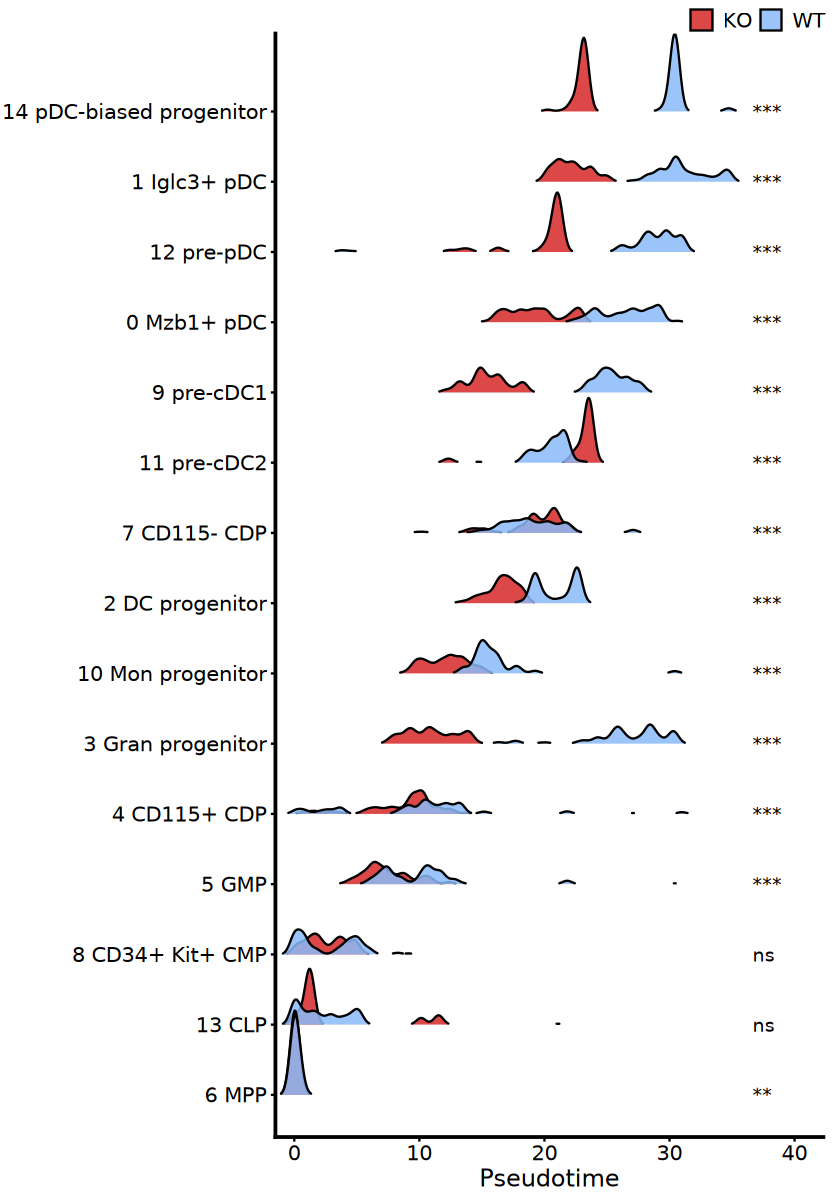

In [12]:
library(ggplot2)
library(dplyr)
library(ggridges)

# ===================================================================
# 1. 准备数据
# ===================================================================

# !!! 关键修改：请确认你的 CDS 对象里存放细胞类型的列名 !!!
# 常见的可能是: "celltype", "seurat_clusters", "Cluster", "active.ident"
target_col_name <- "celltype" 

# 检查列名是否存在 (防止报错)
if (!target_col_name %in% names(colData(wt_cds))) {
  warning(paste0("列名 '", target_col_name, "' 未在对象中找到！\n",
                 "请检查 names(colData(wt_cds)) 并修改 target_col_name 变量。\n",
                 "目前可用列名: ", paste(head(names(colData(wt_cds))), collapse=", ")))
  # 为了防止代码崩溃，如果你没改，这里可能会尝试使用 seurat_clusters 作为备选
  if("seurat_clusters" %in% names(colData(wt_cds))) target_col_name <- "seurat_clusters"
}

# 定义提取函数
extract_data_celltype <- function(cds, group_label) {
  pt <- pseudotime(cds)
  meta <- as.data.frame(colData(cds))
  
  # 确保有 pseudotime
  valid_cells <- is.finite(pt)
  
  df <- data.frame(
    Barcode = rownames(meta)[valid_cells],
    Pseudotime = pt[valid_cells],
    orig.ident = group_label,
    celltype = meta[valid_cells, target_col_name]
  )
  return(df)
}

# 提取数据 (使用你在第一步生成的 wt_cds 和 ko_cds)
df_wt_ct <- extract_data_celltype(wt_cds, "WT")
df_ko_ct <- extract_data_celltype(ko_cds, "KO")
df_all_ct <- rbind(df_wt_ct, df_ko_ct)

# 清洗数据：移除 NA 的细胞类型
df_all_ct <- df_all_ct[!is.na(df_all_ct$celltype), ]

# ===================================================================
# 2. 排序 (按照 Pseudotime 中位数排序)
# ===================================================================
# 这步很重要：让处于发育早期的细胞排在下面，晚期的排在上面
type_order <- df_all_ct %>%
  group_by(celltype) %>%
  summarise(median_pt = median(Pseudotime, na.rm = TRUE)) %>%
  arrange(median_pt) %>%
  pull(celltype)

df_all_ct$celltype <- factor(df_all_ct$celltype, levels = type_order)

# ===================================================================
# 3. 计算统计显著性 (Wilcoxon test)
# ===================================================================
stats_ct <- data.frame(celltype = levels(df_all_ct$celltype), p_label = "", stringsAsFactors = FALSE)

for(i in 1:nrow(stats_ct)) {
  ct <- stats_ct$celltype[i]
  sub_dat <- subset(df_all_ct, celltype == ct)
  
  wt_vals <- sub_dat[sub_dat$orig.ident == "WT", "Pseudotime"]
  ko_vals <- sub_dat[sub_dat$orig.ident == "KO", "Pseudotime"]
  
  # 只有当两组细胞数都足够时才计算
  if(length(wt_vals) > 10 && length(ko_vals) > 10) {
    p_val <- wilcox.test(wt_vals, ko_vals)$p.value
    if(p_val < 0.001) {
      stats_ct$p_label[i] <- "***"
    } else if(p_val < 0.01) {
      stats_ct$p_label[i] <- "**"
    } else if(p_val < 0.05) {
      stats_ct$p_label[i] <- "*"
    } else {
      stats_ct$p_label[i] <- "ns"
    }
  }
}

# ===================================================================
# 4. 绘图 (出版级风格)
# ===================================================================
# 使用你指定的颜色
my_colors <- c("WT" = "#8abbf9", "KO" = "#D62728")

p_ridge_ct <- ggplot(df_all_ct, aes(x = Pseudotime, y = celltype, fill = orig.ident)) +
  
  # --- 核心绘图层 ---
  geom_density_ridges(
    scale = 1.2,           # 峰高度
    alpha = 0.85,          # 透明度
    color = "black",       # 黑色描边
    size = 0.3,            # 描边粗细 (0.3-0.5 比较精致)
    rel_min_height = 0.01, # 忽略极小的尾部
    quantile_lines = FALSE # 不画分位数线，保持画面整洁
  ) +
  
  scale_fill_manual(values = my_colors) +
  
  # --- 统计标记 ---
  geom_text(data = stats_ct, 
            aes(x = max(df_all_ct$Pseudotime) * 1.05, y = celltype, label = p_label), 
            inherit.aes = FALSE, 
            hjust = 0, vjust = 0.5, 
            size = 4, fontface = "bold", color = "black") + 
  
  # --- 标签规范化 ---
  labs(
    x = "Pseudotime",      # 标准写法
    y = NULL,              # 移除 Y 轴标题 (因为刻度已经是细胞名了)
    title = NULL,          # 移除标题 (写在图注里)
    fill = NULL            # 移除图例标题
  ) +
  
  # --- 主题设置 ---
  theme_classic() +
  theme(
    # 坐标轴
    axis.line = element_line(linewidth = 0.8, color = "black"),
    axis.text.x = element_text(size = 12, color = "black"),
    axis.text.y = element_text(size = 12, color = "black", face = "plain"), # 细胞名称保持清晰
    axis.title.x = element_text(size = 14, face = "bold"),
    
    # 图例 (放顶部或内部，节省空间)
    legend.position = "top", 
    legend.justification = "right", # 图例靠右对齐
    legend.text = element_text(size = 12),
    legend.key.size = unit(0.5, "cm"),
    legend.margin = margin(b = -10), # 减少图例和图之间的空白
    
    # 边距 (给右边的星号留出空间)
    plot.margin = margin(5, 10, 5, 20) 
  ) +
  
  # 扩展 X 轴范围，防止星号被切掉
  scale_x_continuous(expand = expansion(mult = c(0.01, 0.15)))

# 打印
options(repr.plot.width = 7, repr.plot.height = 10) # 竖长图适合 Ridge plot
print(p_ridge_ct)

In [14]:
library(ggplot2)

# ===================================================================
# 1. 设置保存路径
# ===================================================================
# 定义目标文件夹路径
out_dir <- p38_path("20260126p38拟时序修图")

# 检查文件夹是否存在，如果不存在则递归创建
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
  message(paste("已创建文件夹:", out_dir))
} else {
  message(paste("文件夹已存在:", out_dir))
}

# ===================================================================
# 2. 保存 PDF 文件
# ===================================================================

# --- 保存 p_density_pub (密度图) ---
# 建议尺寸: 宽6英寸, 高4.5英寸 (适合标准单栏或半版插图)
ggsave(
  filename = file.path(out_dir, "Pseudotime_Density_Distribution.pdf"),
  plot = p_density_pub, 
  width = 4, 
  height = 4, 
  device = "pdf"
)
message("成功保存: Pseudotime_Density_Distribution.pdf")

# --- 保存 p_ridge_ct (山峦图) ---
# 建议尺寸: 宽6英寸, 高8英寸 (山峦图通常是纵向的，高度需要大一些以容纳所有细胞类型)
ggsave(
  filename = file.path(out_dir, "Pseudotime_RidgePlot_CellType.pdf"),
  plot = p_ridge_ct, 
  width = 6, 
  height = 8, 
  device = "pdf"
)
message("成功保存: Pseudotime_RidgePlot_CellType.pdf")

文件夹已存在: /data3/Group8/gonglihao/项目/p38/20260126p38拟时序修图

成功保存: Pseudotime_Density_Distribution.pdf

Picking joint bandwidth of 0.376

成功保存: Pseudotime_RidgePlot_CellType.pdf

